# OTFS Equalizer Benchmark

Self-contained reproduction of the BLER and latency results for the OTFS Equalizer Design task. The compared equalizers are `LMMSE`, `MP`, `EP`, `UAMP`, and the selected solution `gen58-1877`.

The Monte-Carlo settings below are reduced for interactive runtime. Raise `MAX_MC_ITER` / `TARGET_BLOCK_ERRORS` to approach the results of the paper — the high-SNR (low-BLER) points need the most trials.

Latency measurements should be carried out in a separate process, e.g., by running
```
jupyter nbconvert --to script --stdout OTFS.ipynb | python
```

## Configuration and Imports

In [1]:
import sys, time, gc, importlib.util
from pathlib import Path

_ROOT = Path.cwd()  # notebook runs in tasks/otfs_detector
if str(_ROOT) not in sys.path:
    sys.path.insert(0, str(_ROOT))

import torch
import matplotlib.pyplot as plt

import sionna
from sionna.phy.fec.ldpc import LDPC5GEncoder, LDPC5GDecoder
from sionna.phy.mapping import Mapper
from sionna.phy.utils import sim_ber

from otfs import ResourceGrid, MultipathChannel, RectCPOtfsIO, ChannelView
from otfs.equalizers import LMMSE, MP, EP, UAMP

DEVICE = "cuda:0" if torch.cuda.is_available() else "cpu"
sionna.phy.config.device = DEVICE
print("device:", DEVICE)

device: cuda:0


## Load Selected Solution 

In [2]:
def load_selected_solution():
    """Import the selected detector (gen58-1877) with its coded defaults.

    HP.get() reads hyperparams.json if present; we clear it so the detector
    uses the coded defaults (top_k=2560, maxlog) that produced the figure.
    """
    sol = _ROOT / "selected_solution"
    if str(sol) not in sys.path:
        sys.path.insert(0, str(sol))
    import hp
    hp.HP._params, hp.HP._loaded = {}, True
    spec = importlib.util.spec_from_file_location("selected_draft", sol / "draft.py")
    mod = importlib.util.module_from_spec(spec)
    sys.modules[spec.name] = mod  # register so torch.compile can trace the module's globals
    spec.loader.exec_module(mod)
    return mod.EC2RichardsonAPPDetector


SelectedSolution = load_selected_solution()

## System Configuration

In [ ]:
M = N = 64 # Number of delay and doppler bins
SCS = 15e3 # Subcarrier spacing
FC = 4.0e9 # Carrier frequency
CP = 16 # Cyclic prefix length
PROFILE = "continuous-p6" # Channel profile
NUM_PATHS = 6 # Number of paths
DELAY_SPREAD_BINS = 14.0 # Maximum delay spread in bins
K_SYM_MAX = 0.5 # Maximum number of symbols per frame
DELAY_WINDOW = DOPPLER_WINDOW = 5 # Delay and Doppler window size
FULL_PERIOD_IO = True # Whether to use full period OFDM symbols for training
NUM_BITS = 4 # Number of bits per symbol
LDPC_RATE = 0.5 # LDPC code rate
LDPC_ITERS = 20 # Number of LDPC decoding iterations
PRECISION = "single" # Precision
SEED = 0 # Random seed

# Monte-Carlo sweep (reduced for runtime; raise for smoother low-BLER points)
SNR_DB = [12.0, 14.0, 16.0, 17.0]
BATCH = 8
TARGET_BLOCK_ERRORS = 100
MAX_MC_ITER = 1000

# (label, class, top_k, kwargs) -- hyperparameters from benchmark/config.py
EQUALIZERS = [
    ("LMMSE",      LMMSE,            M * N, {}),
    ("MP",         MP,               512,   dict(num_iterations=15, damping=0.6, gamma=0.05, epsilon=0.2)),
    ("EP",         EP,               512,   dict(num_iterations=15, damping=0.5)),
    ("UAMP",       UAMP,             2048,  dict(num_iters=10, estimate_noise=True)),
    ("gen58-1877", SelectedSolution, 2560,  {}),
]

## Coded OTFS link

`Link` wires up the transmit + channel + receiver pipeline (random bits → 5G LDPC → 16-QAM → analytical DD channel + AWGN → equalizer → LDPC decode) around a swappable equalizer. Will be used for benchmarking of different equalizers.

In [4]:
class Link:
    """Coded OTFS link (5G LDPC + 16-QAM + analytical DD channel) with a swappable equalizer."""

    def __init__(self, eq_cls, top_k, eq_kwargs):
        self.top_k = top_k
        self.grid = ResourceGrid(
            num_delay_bins=M, num_doppler_bins=N, subcarrier_spacing=SCS,
            carrier_frequency=FC, cp_samples=CP, precision=PRECISION, device=DEVICE,
        )
        self.dtype = self.grid.dtype
        self.channel = MultipathChannel(
            self.grid, profile=PROFILE, num_paths=NUM_PATHS,
            l_max=DELAY_SPREAD_BINS, k_sym_max=K_SYM_MAX,
        )
        self.io = RectCPOtfsIO(
            self.grid, delay_window=DELAY_WINDOW,
            doppler_window=DOPPLER_WINDOW, full_period=FULL_PERIOD_IO,
        )
        n_coded = M * N * NUM_BITS
        self.k_info = round(LDPC_RATE * n_coded)
        self.encoder = LDPC5GEncoder(k=self.k_info, n=n_coded, precision=PRECISION, device=DEVICE)
        self.decoder = LDPC5GDecoder(
            self.encoder, num_iter=LDPC_ITERS, hard_out=True,
            return_infobits=True, precision=PRECISION, device=DEVICE,
        )
        self.mapper = Mapper(
            constellation_type="qam", num_bits_per_symbol=NUM_BITS,
            precision=PRECISION, device=DEVICE,
        )
        self.eq = eq_cls(self.grid, num_bits_per_symbol=NUM_BITS,
                         precision=PRECISION, device=DEVICE, **eq_kwargs)

    def _view(self, cir):
        sparse = self.io.sparse(cir, top_k=self.top_k)
        if self.eq.channel_form == "dense":
            return ChannelView(cir=cir, sparse=None, dense=sparse.to_dense())
        return ChannelView(cir=cir, sparse=sparse, dense=None)

    def sample(self, batch, snr_db):
        """One TX + channel realisation -> (bits, y_dd, channel view, per-frame noise var)."""
        no = 10.0 ** (-torch.as_tensor(snr_db, dtype=self.dtype, device=DEVICE) / 10.0)
        cir = self.channel(batch)
        u = (torch.rand(batch, self.k_info, dtype=self.dtype, device=DEVICE) > 0.5).to(self.dtype)
        y = self.io.apply(self.mapper(self.encoder(u)), cir, noise_variance=no)
        return u, y, self._view(cir), no.expand(batch)

    def mc_fun(self, batch_size, ebno_db):
        u, y, view, no = self.sample(batch_size, ebno_db)
        return u, self.decoder(self.eq.llr(y, view, no))

## BER/BLER and latency functions

`simulate_ber_bler` runs a seeded `sim_ber` Monte-Carlo sweep. `measure_latency` times only `equalizer.llr` (compiled with `torch.compile`) on one realistic input batch built outside the timed region, and reports milliseconds per batch.

In [5]:
def simulate_ber_bler(spec):
    """Seeded Monte-Carlo coded BER/BLER sweep for one equalizer spec."""
    _, eq_cls, top_k, kwargs = spec
    torch.manual_seed(SEED)
    link = Link(eq_cls, top_k, kwargs)
    ebno = torch.tensor(SNR_DB, dtype=link.dtype, device=DEVICE)
    ber, bler = sim_ber(
        mc_fun=link.mc_fun, ebno_dbs=ebno, batch_size=BATCH,
        max_mc_iter=MAX_MC_ITER, num_target_block_errors=TARGET_BLOCK_ERRORS,
        target_bler=0.0, early_stop=True, soft_estimates=False, verbose=True,
        compile_mode="default"
    )
    return ber.detach().cpu().tolist(), bler.detach().cpu().tolist()


def measure_latency(spec, snr_db=14.5, frames=40, warmup=10):
    """Per-frame runtime (ms) of a compiled equalizer.llr on one realistic input batch.

    Resets Dynamo and frees cached GPU memory first, so a preceding BLER
    sweep cannot perturb the timing.
    """
    torch._dynamo.reset()
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    _, eq_cls, top_k, kwargs = spec
    link = Link(eq_cls, top_k, kwargs)

    torch.manual_seed(SEED + 10_000)
    with torch.no_grad():
        # One realistic (y_dd, channel view, noise) batch; the transmit/channel
        # pipeline is built here, outside the timed region.
        y_dd, view, no = link.sample(BATCH, snr_db)[1:]
        fn = link.eq.llr
        try:
            fn = torch.compile(link.eq.llr, mode="default", dynamic=False)
            for _ in range(warmup):  # warm up + trigger compilation
                fn(y_dd, view, no)
        except Exception:
            torch._dynamo.reset()
            fn = link.eq.llr
            for _ in range(warmup):
                fn(y_dd, view, no)

        if torch.cuda.is_available():
            torch.cuda.synchronize()
        t0 = time.perf_counter()
        for _ in range(frames):
            fn(y_dd, view, no)
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        elapsed = time.perf_counter() - t0

    # elapsed covers `frames` calls, each on a batch of BATCH frames.
    return (elapsed / frames) * 1e3

## Run BLER sweeps

First phase: run the Monte-Carlo BER/BLER sweep for each detector and collect the curves. Latency is measured separately in the next section so the memory-heavy sweeps can't perturb the timing. This is the long-running cell; the low-BLER points at high SNR dominate the time.

In [6]:
results = []
for spec in EQUALIZERS:
    label = spec[0]
    print(f"[BLER] {label} ...", flush=True)
    ber, bler = simulate_ber_bler(spec)
    results.append(dict(label=label, top_k=spec[2], ber=ber, bler=bler))
    print(f"       BLER={['%.2e' % v for v in bler]}", flush=True)

[BLER] LMMSE ...
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     12.0 | 2.2174e-02 | 2.4510e-01 |       74114 |     3342336 |          100 |         408 |        26.8 |reached target block errors
     14.0 | 4.8974e-03 | 5.5310e-02 |       72536 |    14811136 |          100 |        1808 |       107.2 |reached target block errors
     16.0 | 4.2903e-04 | 6.7500e-03 |       28117 |    65536000 |           54 |        8000 |       488.5 |reached max iterations
     17.0 | 1.8013e-04 | 2.6250e-03 |       11805 |    65536000 |           21 |        8000 |       488.9 |reached max iterations
       BLER=['2.45e-01', '5.53e-02', '6.75e-03', '2.62e-03']
[BLER] MP ...
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status


## Measure latency

`measure_latency` times only `equalizer.llr` on one realistic input batch and reports milliseconds per batch.

The numbers below are indicative only. For **reliable** latency, run this benchmark as a standalone script in a fresh process on an otherwise-idle GPU, not in a notebook kernel.

In [7]:
for r, spec in zip(results, EQUALIZERS):
    r["latency"] = measure_latency(spec)
    print(f"[lat] {r['label']:12s} {r['latency']:.3f} ms/batch", flush=True)

[lat] LMMSE        461.436 ms/batch
[lat] MP           199.102 ms/batch
[lat] EP           76.513 ms/batch
[lat] UAMP         21.545 ms/batch
[lat] gen58-1877   3.226 ms/batch


## Coded BER and BLER

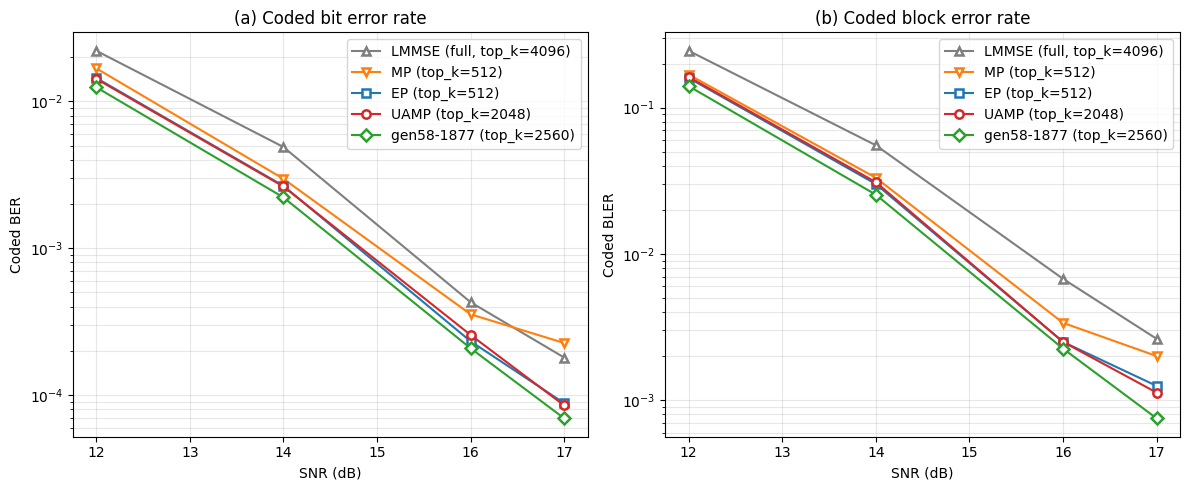

In [8]:
# Fixed color/marker per detector so the panels match the shipped figure.
STYLE = {
    "LMMSE": ("#7f7f7f", "^"),
    "MP": ("#ff7f0e", "v"),
    "EP": ("#1f77b4", "s"),
    "UAMP": ("#d62728", "o"),
    "gen58-1877": ("#2ca02c", "D"),
}


def _legend(r):
    tag = f"full, top_k={r['top_k']}" if r["top_k"] >= M * N else f"top_k={r['top_k']}"
    return f"{r['label']} ({tag})"


fig, (ax_ber, ax_bler) = plt.subplots(1, 2, figsize=(12, 5))
for r in results:
    color, marker = STYLE[r["label"]]
    ax_ber.semilogy(SNR_DB, [max(v, 1e-7) for v in r["ber"]], marker=marker, color=color,
                    label=_legend(r), markerfacecolor="white", markeredgewidth=1.8)
    ax_bler.semilogy(SNR_DB, [max(v, 1e-5) for v in r["bler"]], marker=marker, color=color,
                     label=_legend(r), markerfacecolor="white", markeredgewidth=1.8)

ax_ber.set(xlabel="SNR (dB)", ylabel="Coded BER", title="(a) Coded bit error rate")
ax_bler.set(xlabel="SNR (dB)", ylabel="Coded BLER", title="(b) Coded block error rate")
for ax in (ax_ber, ax_bler):
    ax.grid(True, which="both", alpha=0.3)
    ax.legend()
fig.tight_layout()
plt.show()

## Inference latency

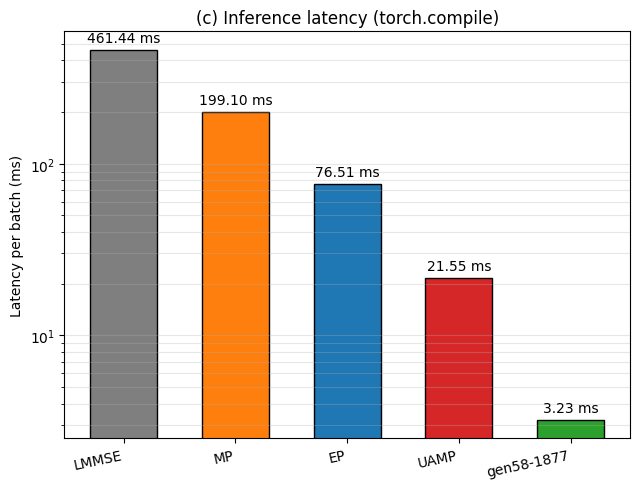

In [9]:
labels = [r["label"] for r in results]
lats = [r["latency"] for r in results]
colors = [STYLE[l][0] for l in labels]

fig, ax = plt.subplots(figsize=(6.5, 5))
bars = ax.bar(range(len(results)), lats, color=colors, edgecolor="black", width=0.6)
ax.set_yscale("log")
ax.set_xticks(range(len(results)))
ax.set_xticklabels(labels, rotation=12, ha="right")
ax.set_ylabel("Latency per batch (ms)")
ax.set_title("(c) Inference latency (torch.compile)")
ax.grid(True, axis="y", which="both", alpha=0.3)
for bar, value in zip(bars, lats):
    ax.text(bar.get_x() + bar.get_width() / 2, value * 1.07, f"{value:.2f} ms",
            ha="center", va="bottom", fontsize=10)
fig.tight_layout()
plt.show()